In [1]:
# Install if needed
!pip install lightgbm scikit-learn pandas numpy matplotlib seaborn

# Imports
import pandas as pd
import numpy as np
import lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Load dataset
df = pd.read_csv(r"C:\Users\mojes\Desktop\IDS PROJECT\dataset\train_test_network.csv")  

# Quick inspection
print(df.shape)
df.head()

(211043, 44)


,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,-,290.371539,101568,2592,OTH,...,0,0,-,-,-,-,-,-,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000102,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000148,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000113,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000130,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor


In [4]:
# Remove duplicates
df = df.drop_duplicates()

# Fill missing values
df = df.fillna(0)

# Verify
print("Shape after cleaning:", df.shape)

Shape after cleaning: (190474, 44)


In [5]:
# Binary target (already exists)
y_binary = df['label']

# Multiclass target
y_multi = df['type']

# Features
X = df.drop(columns=['label', 'type'])

In [6]:
X = X.drop(columns=['src_ip', 'dst_ip'])

In [7]:
print(X.dtypes)

src_port                    int64
dst_port                    int64
proto                         str
service                       str
duration                  float64
src_bytes                   int64
dst_bytes                   int64
conn_state                    str
missed_bytes                int64
src_pkts                    int64
src_ip_bytes                int64
dst_pkts                    int64
dst_ip_bytes                int64
dns_query                     str
dns_qclass                  int64
dns_qtype                   int64
dns_rcode                   int64
dns_AA                        str
dns_RD                        str
dns_RA                        str
dns_rejected                  str
ssl_version                   str
ssl_cipher                    str
ssl_resumed                   str
ssl_established               str
ssl_subject                   str
ssl_issuer                    str
http_trans_depth              str
http_method                   str
http_uri      

In [8]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}  # store encoders (important for future use)

for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

C:\Users\mojes\AppData\Local\Temp\ipykernel_22276\3237331378.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include=['object']).columns:


In [9]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in X.select_dtypes(include=['object', 'string']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

In [10]:
print("Shape:", X.shape)
print("Null values:", X.isnull().sum().sum())
print("Dtypes:\n", X.dtypes.value_counts())

Shape: (190474, 40)
Null values: 0
Dtypes:
 int64      39
float64     1
Name: count, dtype: int64


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, yb_train, yb_test, ym_train, ym_test = train_test_split(
    X, y_binary, y_multi,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

In [12]:
import lightgbm as lgb

binary_model = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

binary_model.fit(X_train, yb_train)

[LightGBM] [Info] Number of positive: 118747, number of negative: 33632
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019429 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2668
[LightGBM] [Info] Number of data points in the train set: 152379, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.779287 -> initscore=1.261517
[LightGBM] [Info] Start training from score 1.261517


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [13]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

yb_pred = binary_model.predict(X_test)

acc = accuracy_score(yb_test, yb_pred)
cm = confusion_matrix(yb_test, yb_pred)

print("Binary Accuracy:", acc)
print("\nClassification Report:\n", classification_report(yb_test, yb_pred))
print("\nConfusion Matrix:\n", cm)

Binary Accuracy: 0.9989499934374589

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      8408
           1       1.00      1.00      1.00     29687

    accuracy                           1.00     38095
   macro avg       1.00      1.00      1.00     38095
weighted avg       1.00      1.00      1.00     38095


Confusion Matrix:
 [[ 8383    25]
 [   15 29672]]


In [14]:
TP = cm[1,1]
TN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]

FPR = FP / (FP + TN)
FNR = FN / (FN + TP)
Detection_Rate = TP / (TP + FN)

print(f"FPR: {FPR:.6f}")
print(f"FNR: {FNR:.6f}")
print(f"Detection Rate: {Detection_Rate:.6f}")

FPR: 0.002973
FNR: 0.000505
Detection Rate: 0.999495


In [15]:
multi_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    objective='multiclass',
    random_state=42
)

multi_model.fit(X_train, ym_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018291 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2668
[LightGBM] [Info] Number of data points in the train set: 152379, number of used features: 36
[LightGBM] [Info] Start training from score -2.323735
[LightGBM] [Info] Start training from score -2.251348
[LightGBM] [Info] Start training from score -2.305470
[LightGBM] [Info] Start training from score -2.254657
[LightGBM] [Info] Start training from score -5.209092
[LightGBM] [Info] Start training from score -1.510893
[LightGBM] [Info] Start training from score -2.260618
[LightGBM] [Info] Start training from score -2.559034
[LightGBM] [Info] Start training from score -2.253032
[LightGBM] [Info] Start training from score -2.534654
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [16]:
from sklearn.metrics import accuracy_score, classification_report

ym_pred = multi_model.predict(X_test)

print("Multiclass Accuracy:", accuracy_score(ym_test, ym_pred))
print("\nClassification Report:\n", classification_report(ym_test, ym_pred))

Multiclass Accuracy: 0.9898936868355427

Classification Report:
               precision    recall  f1-score   support

    backdoor       1.00      1.00      1.00      3792
        ddos       0.99      0.98      0.99      3954
         dos       0.99      0.98      0.98      3798
   injection       0.98      0.98      0.98      3978
        mitm       0.72      0.82      0.77       208
      normal       1.00      1.00      1.00      8408
    password       0.99      0.99      0.99      3970
  ransomware       1.00      1.00      1.00      2944
    scanning       0.99      0.99      0.99      3988
         xss       0.97      0.99      0.98      3055

    accuracy                           0.99     38095
   macro avg       0.96      0.97      0.97     38095
weighted avg       0.99      0.99      0.99     38095



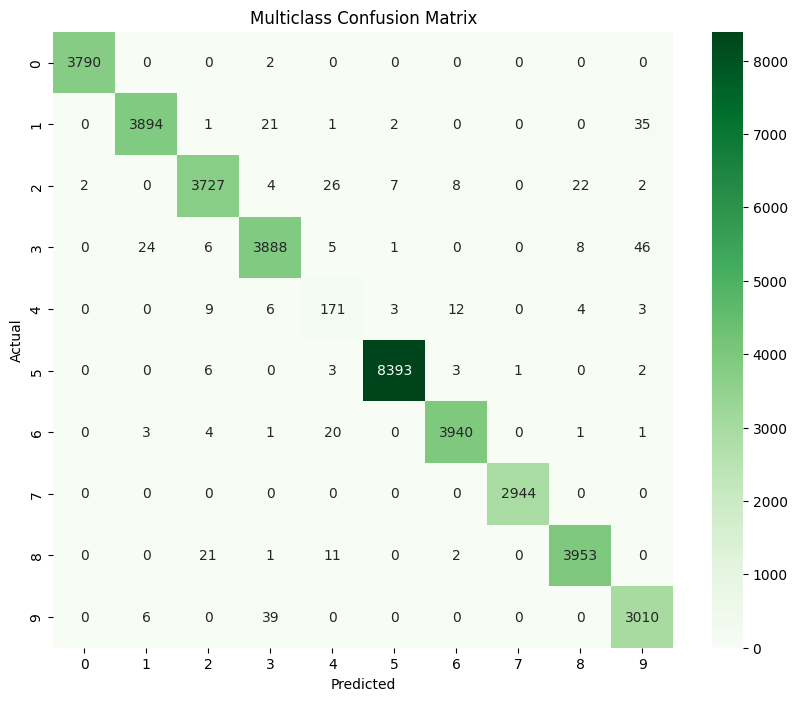

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_multi = confusion_matrix(ym_test, ym_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Greens')
plt.title("Multiclass Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_macro = precision_score(ym_test, ym_pred, average='macro')
recall_macro = recall_score(ym_test, ym_pred, average='macro')
f1_macro = f1_score(ym_test, ym_pred, average='macro')

precision_weighted = precision_score(ym_test, ym_pred, average='weighted')
recall_weighted = recall_score(ym_test, ym_pred, average='weighted')
f1_weighted = f1_score(ym_test, ym_pred, average='weighted')

print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1:", f1_macro)

print("\nWeighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1:", f1_weighted)

Macro Precision: 0.9635770620308687
Macro Recall: 0.9732247997563949
Macro F1: 0.9680655536759588

Weighted Precision: 0.9901163062508695
Weighted Recall: 0.9898936868355427
Weighted F1: 0.9899804372723059


In [19]:
import pandas as pd

cm_df = pd.DataFrame(cm_multi)

detection_rates = {}

for i in range(len(cm_df)):
    TP = cm_df.iloc[i, i]
    FN = cm_df.iloc[i].sum() - TP
    detection_rates[i] = TP / (TP + FN)

print("Detection Rate per Class:\n")
for k, v in detection_rates.items():
    print(f"Class {k}: {v:.4f}")

Detection Rate per Class:

Class 0: 0.9995
Class 1: 0.9848
Class 2: 0.9813
Class 3: 0.9774
Class 4: 0.8221
Class 5: 0.9982
Class 6: 0.9924
Class 7: 1.0000
Class 8: 0.9912
Class 9: 0.9853


In [20]:
import joblib

joblib.dump(binary_model, "ton_binary.pkl")
joblib.dump(multi_model, "ton_multi.pkl")
joblib.dump(X.columns.tolist(), "ton_features.pkl")
joblib.dump(label_encoders, "ton_encoders.pkl")

['ton_encoders.pkl']

In [21]:
from IPython.display import FileLink

FileLink("ton_binary.pkl")
FileLink("ton_multi.pkl")
FileLink("ton_features.pkl")
FileLink("ton_encoders.pkl")

C:\Users\mojes\ton_encoders.pkl